In [1]:
import os
import subprocess

GITHUB_USER = "AbrarYasir01"
REPO_NAME = "FashionMNIST-CNN-Assignment"
STUDENT_ID = "220140"

# Clone the repository automatically
if not os.path.exists(REPO_NAME):
    subprocess.run([f"git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git"], shell=True)

CUSTOM_DATA_DIR = os.path.join(REPO_NAME, "dataset")
MODEL_SAVE_DIR = os.path.join(REPO_NAME, "model")
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, f"{STUDENT_ID}.pth")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print("Repository cloned successfully!")

Repository cloned successfully!


In [2]:
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

full_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_train)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform_test)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_set, val_set = random_split(full_train, [train_size, val_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.9MB/s]


In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Save state_dict locally
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved locally at {MODEL_SAVE_PATH}")

Epoch 01/10 | Train Loss: 0.5678 Acc: 0.7991 | Val Loss: 0.3497 Acc: 0.8681
Epoch 02/10 | Train Loss: 0.4048 Acc: 0.8546 | Val Loss: 0.3116 Acc: 0.8853
Epoch 03/10 | Train Loss: 0.3644 Acc: 0.8671 | Val Loss: 0.2809 Acc: 0.8951
Epoch 04/10 | Train Loss: 0.3318 Acc: 0.8798 | Val Loss: 0.2664 Acc: 0.9012
Epoch 05/10 | Train Loss: 0.3148 Acc: 0.8876 | Val Loss: 0.2552 Acc: 0.9074
Epoch 06/10 | Train Loss: 0.2981 Acc: 0.8930 | Val Loss: 0.2487 Acc: 0.9127
Epoch 07/10 | Train Loss: 0.2840 Acc: 0.8973 | Val Loss: 0.2358 Acc: 0.9137
Epoch 08/10 | Train Loss: 0.2746 Acc: 0.9005 | Val Loss: 0.2354 Acc: 0.9149
Epoch 09/10 | Train Loss: 0.2637 Acc: 0.9036 | Val Loss: 0.2330 Acc: 0.9172
Epoch 10/10 | Train Loss: 0.2541 Acc: 0.9085 | Val Loss: 0.2222 Acc: 0.9188
Model saved locally at FashionMNIST-CNN-Assignment/model/220140.pth


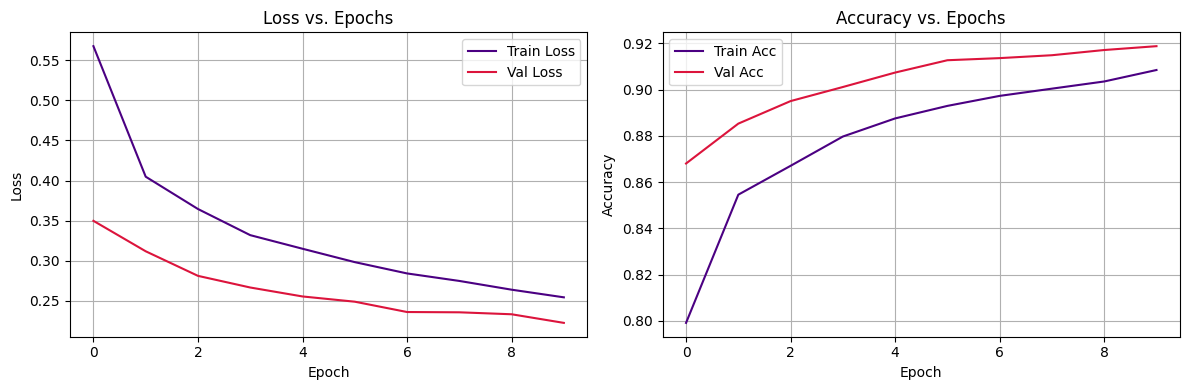

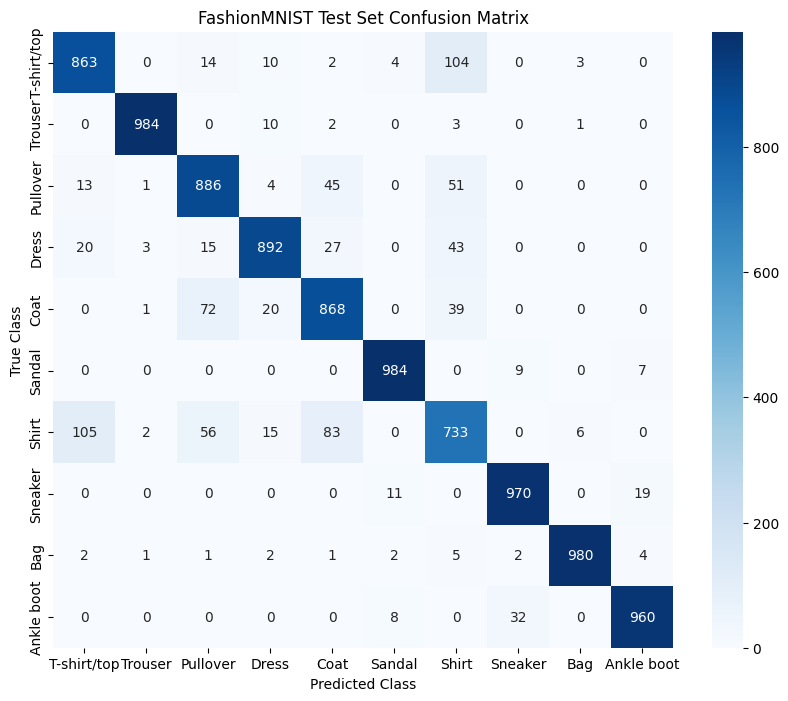

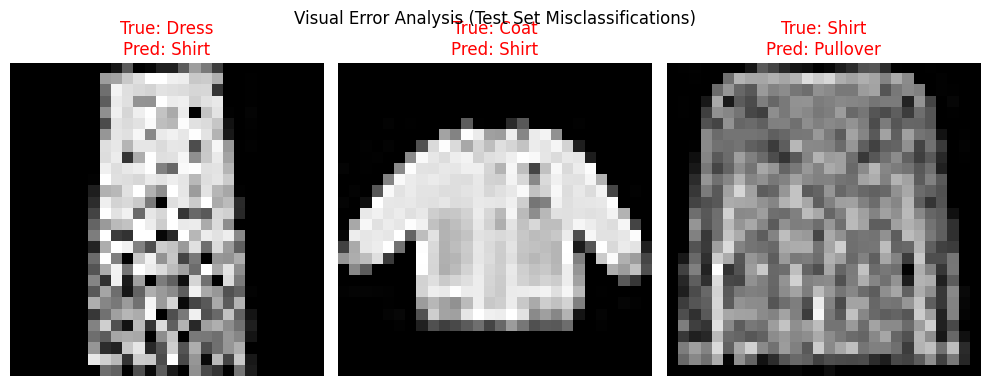

In [6]:
# 1. Training History Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='indigo')
plt.plot(history['val_loss'], label='Val Loss', color='crimson')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='indigo')
plt.plot(history['val_acc'], label='Val Acc', color='crimson')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Confusion Matrix & Misclassifications
model.eval()
all_preds, all_labels, misclassified = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, preds = outputs.max(1)

        preds_cpu = preds.cpu()
        all_preds.extend(preds_cpu.numpy())
        all_labels.extend(labels.numpy())

        for img, lbl, prd in zip(images, labels, preds_cpu):
            if lbl != prd:
                misclassified.append((img, lbl.item(), prd.item()))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('FashionMNIST Test Set Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# 3. Visual Error Analysis (3 Random Misclassified Images)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
samples = random.sample(misclassified, 3)
for idx, (img, true_lbl, pred_lbl) in enumerate(samples):
    img_disp = img.squeeze().numpy() * 0.3530 + 0.2860
    axes[idx].imshow(img_disp, cmap='gray')
    axes[idx].set_title(f"True: {classes[true_lbl]}\nPred: {classes[pred_lbl]}", color='red')
    axes[idx].axis('off')
plt.suptitle('Visual Error Analysis (Test Set Misclassifications)', fontsize=12)
plt.tight_layout()
plt.show()

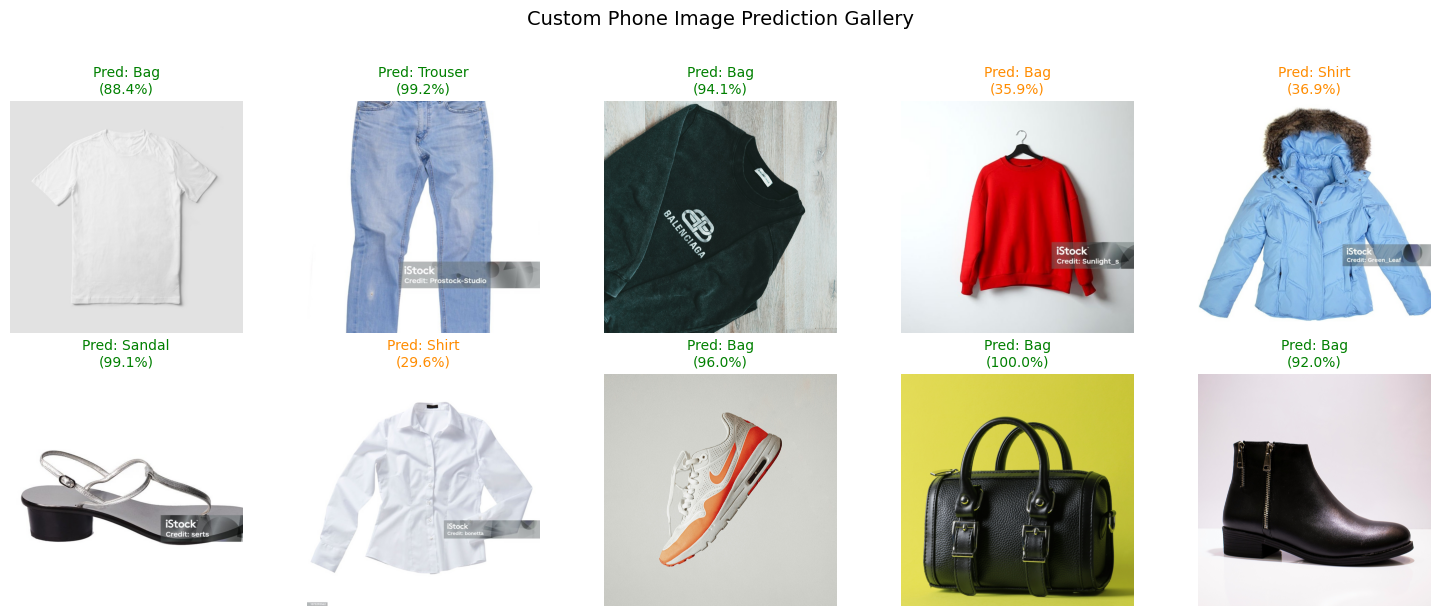

In [7]:
custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

image_paths = sorted(glob.glob(os.path.join(CUSTOM_DATA_DIR, "*.[jJ][pP][gG]")) +
                     glob.glob(os.path.join(CUSTOM_DATA_DIR, "*.[pP][nN][gG]")))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for idx, img_path in enumerate(image_paths[:10]):
        raw_img = Image.open(img_path).convert('RGB')

        # Invert colors if light background so object is light on dark (matching FashionMNIST format)
        inverted_img = ImageOps.invert(raw_img)

        tensor_img = custom_transform(inverted_img).unsqueeze(0).to(device)

        outputs = model(tensor_img)
        probabilities = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probabilities, dim=1)

        pred_label = classes[pred_idx.item()]
        confidence_pct = conf.item() * 100

        axes[idx].imshow(raw_img)
        axes[idx].set_title(f"Pred: {pred_label}\n({confidence_pct:.1f}%)",
                            fontsize=10,
                            color='green' if confidence_pct > 70 else 'darkorange')
        axes[idx].axis('off')

for i in range(len(image_paths), 10):
    axes[i].axis('off')

plt.suptitle('Custom Phone Image Prediction Gallery', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()